In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

BASE_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
DATA_DIR = BASE_DIR / "data" / "preprocessed_rul"

plt.style.use("seaborn-v0_8")

In [3]:
rul_all = pd.read_csv(DATA_DIR / "rul_preprocessed.csv")
rul_train = pd.read_csv(DATA_DIR / "rul_train.csv")
rul_test = pd.read_csv(DATA_DIR / "rul_test.csv")

rul_all.head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct,...,discharge_cycle_index,discharge_duration,avg_temperature,voltage_at_100s,voltage_at_300s,voltage_at_600s,capacity_fade,capacity_derivative,Capacity_normalized,capacity_fade_normalized
0,discharge,[2.0080e+03 4.0000e+00 2.0000e+00 1.5000e+01 2...,24,B0005,1,5122,05122.csv,1.856487,-0.036884,-0.05237,...,0,2.280057,-0.097585,0.473363,0.524596,0.782151,1.008076,0.000000,1.491420,1.491420
1,discharge,[2.0080e+03 4.0000e+00 2.0000e+00 1.9000e+01 4...,24,B0005,3,5124,05124.csv,1.846327,-0.036884,-0.05237,...,1,2.207310,0.093105,0.610459,0.642103,0.848473,1.002559,-0.010160,1.438061,1.438061
2,discharge,[2.008e+03 4.000e+00 3.000e+00 0.000e+00 1.000...,24,B0005,5,5126,05126.csv,1.835349,-0.036884,-0.05237,...,2,2.123124,-0.009623,0.650489,0.685821,0.874904,0.996598,-0.010978,1.380407,1.380407
3,discharge,[2008. 4. 3. 4. 16. ...,24,B0005,7,5128,05128.csv,1.835263,-0.036884,-0.05237,...,3,2.041479,-0.169233,0.695697,0.723826,0.895603,0.996551,-0.000087,1.379952,1.379952
4,discharge,[2008. 4. 3. 8. 33. ...,24,B0005,9,5130,05130.csv,1.834646,-0.036884,-0.05237,...,4,2.031756,-0.334508,0.718977,0.742696,0.907989,0.996216,-0.000617,1.376711,1.376711


In [4]:
print("All data shape:", rul_all.shape)
print("Train shape:", rul_train.shape)
print("Test shape:", rul_test.shape)

print("\nColumns:")
print(rul_all.columns.tolist())

print("\nBasic stats (selected):")
display(
    rul_all[
        ["Capacity", "capacity_fade", "Re", "Rct", "discharge_duration", "avg_temperature", "RUL"]
    ].describe()
)

All data shape: (636, 22)
Train shape: (504, 22)
Test shape: (132, 22)

Columns:
['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct', 'original_cycle_index', 'RUL', 'discharge_cycle_index', 'discharge_duration', 'avg_temperature', 'voltage_at_100s', 'voltage_at_300s', 'voltage_at_600s', 'capacity_fade', 'capacity_derivative', 'Capacity_normalized', 'capacity_fade_normalized']

Basic stats (selected):


,Capacity,capacity_fade,Re,Rct,discharge_duration,avg_temperature,RUL
count,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.00000
mean,1.581652,0.834502,0.083304,0.090598,-0.051017,-0.402842,50.81761
std,0.198765,0.109761,0.909589,0.914475,0.984865,1.211116,45.11708
min,1.153818,0.571898,-2.384660,-2.170653,-1.572389,-3.177451,0.00000
25%,1.421123,0.752709,-0.405151,-0.433937,-0.965876,-1.414223,5.00000
50%,1.559695,0.828844,0.147103,0.080249,-0.183975,-0.351970,45.00000
75%,1.763486,0.932834,0.550503,0.587607,0.741317,0.654154,84.25000
max,2.035338,1.008830,2.071046,2.195230,2.280057,2.294556,167.00000


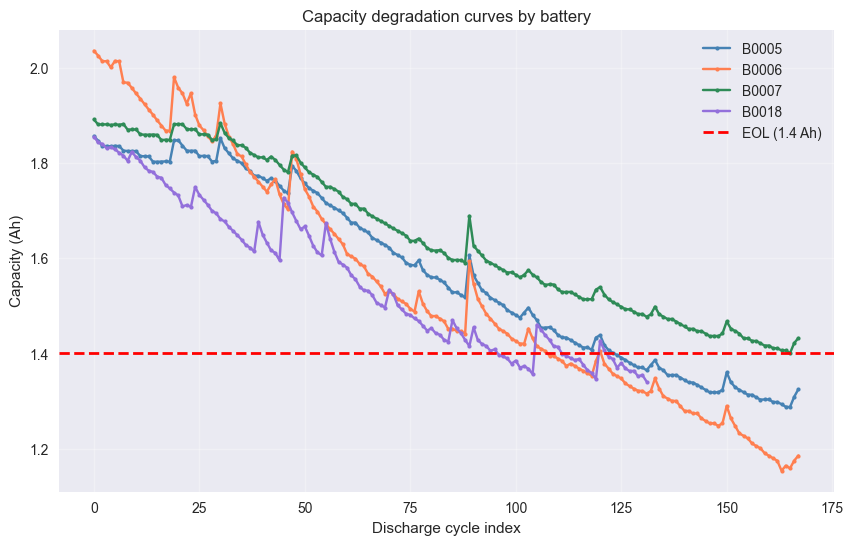

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = {"B0005": "steelblue", "B0006": "coral", "B0007": "seagreen", "B0018": "mediumpurple"}

for bid, df_b in rul_all.groupby("battery_id"):
    df_b = df_b.sort_values("discharge_cycle_index")
    ax.plot(
        df_b["discharge_cycle_index"],
        df_b["Capacity"],
        "o-",
        label=bid,
        color=colors.get(bid, "gray"),
        markersize=3,
    )

ax.axhline(1.4, color="red", linestyle="--", lw=2, label="EOL (1.4 Ah)")
ax.set_xlabel("Discharge cycle index")
ax.set_ylabel("Capacity (Ah)")
ax.set_title("Capacity degradation curves by battery")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

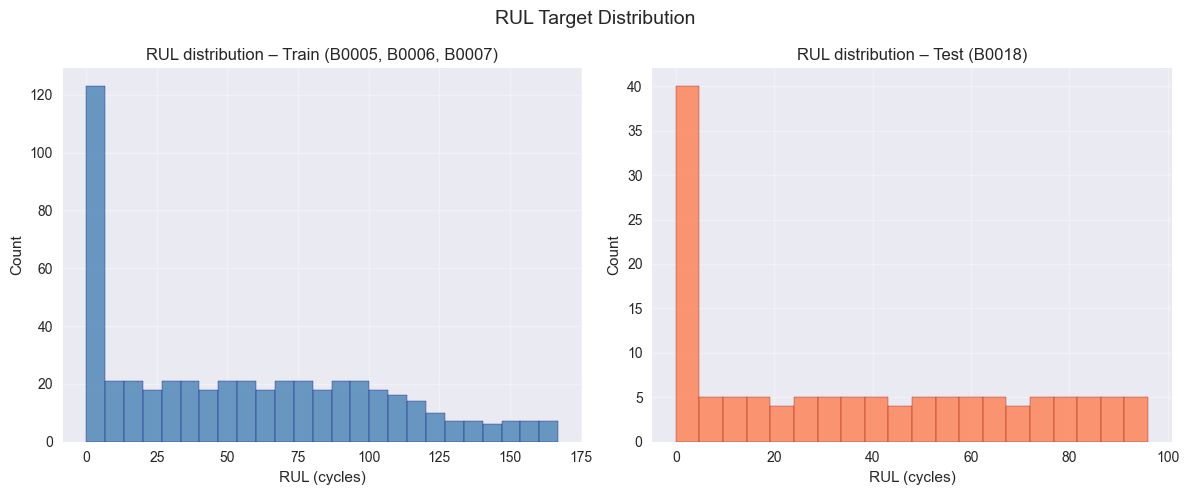

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(rul_train["RUL"], bins=25, color="steelblue", edgecolor="navy", alpha=0.8)
axes[0].set_title("RUL distribution – Train (B0005, B0006, B0007)")
axes[0].set_xlabel("RUL (cycles)")
axes[0].set_ylabel("Count")
axes[0].grid(True, alpha=0.3)

axes[1].hist(rul_test["RUL"], bins=20, color="coral", edgecolor="darkred", alpha=0.8)
axes[1].set_title("RUL distribution – Test (B0018)")
axes[1].set_xlabel("RUL (cycles)")
axes[1].set_ylabel("Count")
axes[1].grid(True, alpha=0.3)

plt.suptitle("RUL Target Distribution", fontsize=14)
plt.tight_layout()
plt.show()

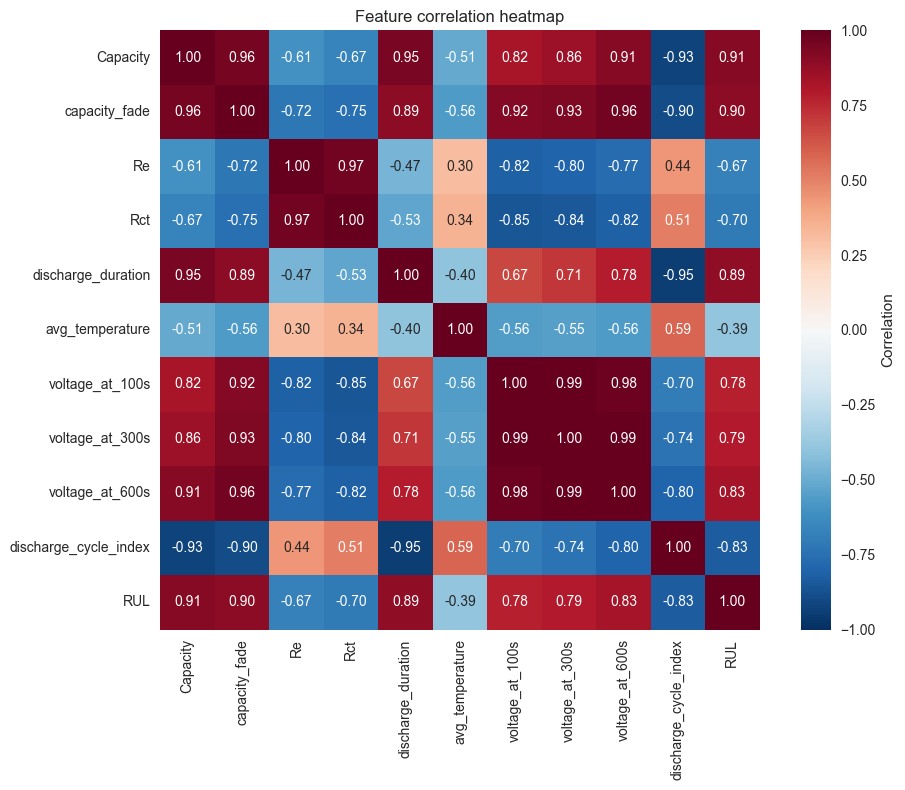

In [7]:
feat_cols = [
    "Capacity",
    "capacity_fade",
    "Re",
    "Rct",
    "discharge_duration",
    "avg_temperature",
    "voltage_at_100s",
    "voltage_at_300s",
    "voltage_at_600s",
    "discharge_cycle_index",
    "RUL",
]
cols = [c for c in feat_cols if c in rul_all.columns]

corr = rul_all[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws={"label": "Correlation"},
)
plt.title("Feature correlation heatmap")
plt.tight_layout()
plt.show()

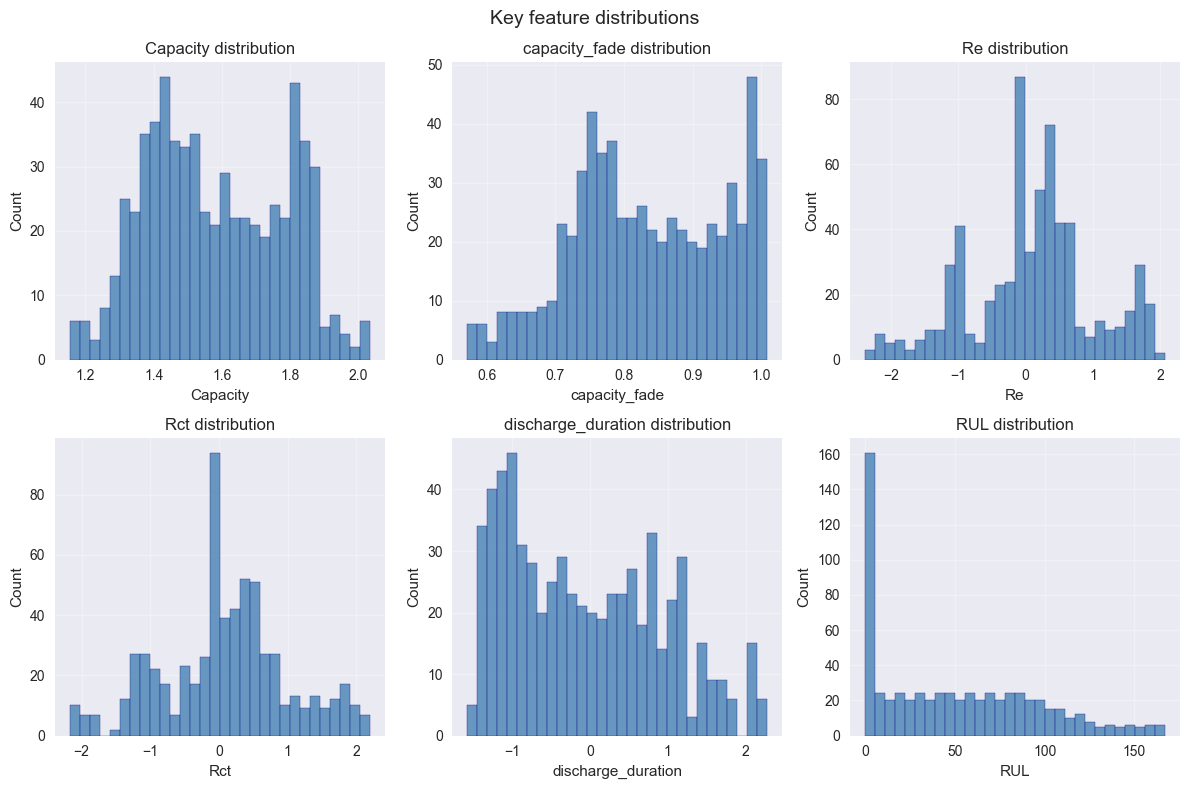

In [9]:
cols = ["Capacity", "capacity_fade", "Re", "Rct", "discharge_duration", "RUL"]
cols = [c for c in cols if c in rul_all.columns]

n = len(cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = np.atleast_2d(axes)

for idx, col in enumerate(cols):
    r, c = divmod(idx, ncols)
    ax = axes[r, c]
    ax.hist(rul_all[col].dropna(), bins=30, color="steelblue", edgecolor="navy", alpha=0.8)
    ax.set_title(f"{col} distribution")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.grid(True, alpha=0.3)

for idx in range(n, nrows * ncols):
    r, c = divmod(idx, ncols)
    axes[r, c].axis("off")

plt.suptitle("Key feature distributions", fontsize=14)
plt.tight_layout()
plt.show()

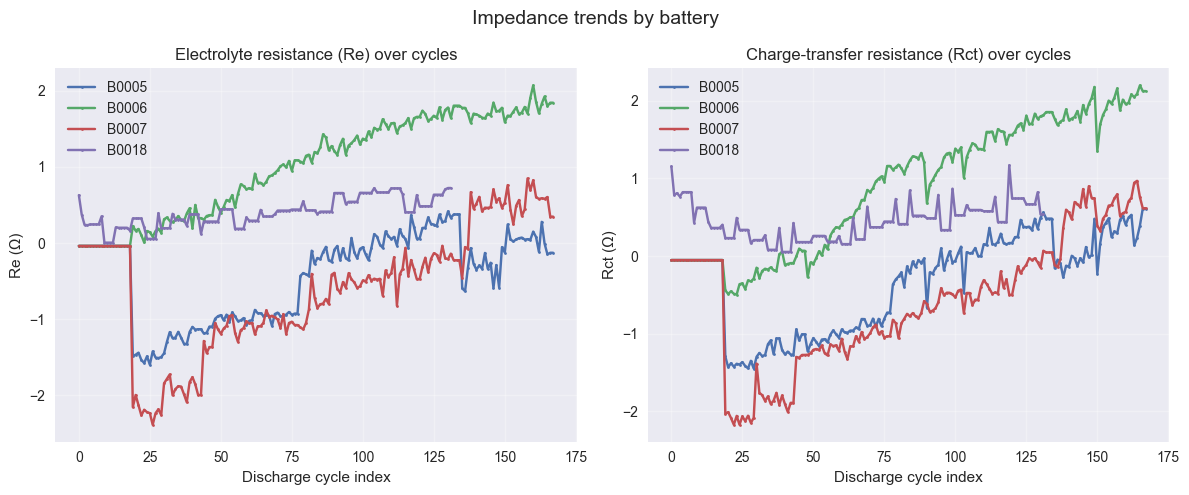

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for bid, df_b in rul_all.groupby("battery_id"):
    df_b = df_b.sort_values("discharge_cycle_index")
    if "Re" in df_b.columns:
        axes[0].plot(df_b["discharge_cycle_index"], df_b["Re"], "o-", label=bid, markersize=2)
    if "Rct" in df_b.columns:
        axes[1].plot(df_b["discharge_cycle_index"], df_b["Rct"], "o-", label=bid, markersize=2)

axes[0].set_xlabel("Discharge cycle index")
axes[0].set_ylabel("Re (Ω)")
axes[0].set_title("Electrolyte resistance (Re) over cycles")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Discharge cycle index")
axes[1].set_ylabel("Rct (Ω)")
axes[1].set_title("Charge-transfer resistance (Rct) over cycles")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Impedance trends by battery", fontsize=14)
plt.tight_layout()
plt.show()